In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform

# Simulation and estimation in a Markov model of breast cancer

# Part 1: A discrete-time model

## Task 1

In [2]:
def sim_liftime_women(P):
   possible_states = np.arange(5)
   state_history = [0]
   current_state = 0

   while current_state != 4:
    current_state = np.random.choice(possible_states, p = P[current_state])
    state_history.append(current_state)

   return np.array(state_history)

In [3]:
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])
sim_liftime_women(P)

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 4])

In [4]:
np.random.seed(42)


P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

n = 1000
life_time = []
women_with_local_cancer = 0

for i in range(n):
    X = sim_liftime_women(P)
    life_time.append(len(X))
    if 1 in X: 
        women_with_local_cancer += 1
    elif 3 in X: 
        women_with_local_cancer += 1

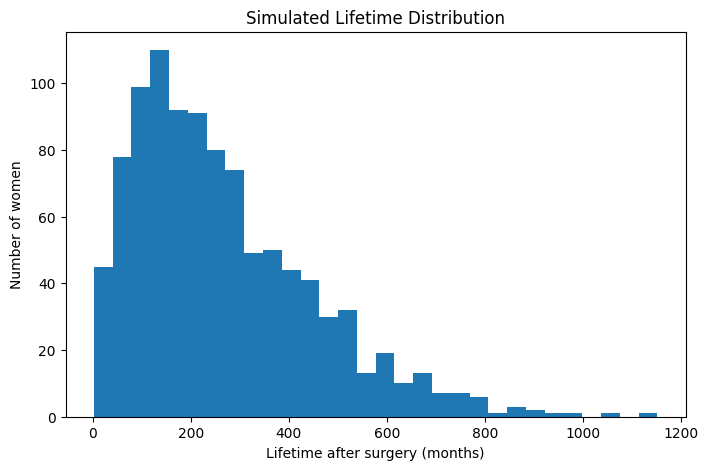

In [5]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(life_time, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

In [6]:
women_with_local_cancer/n

0.712

## Task 2

In [7]:
# Theoretical distribution at time 120 
p0 = np.array([1, 0, 0, 0, 0])
n = 1000
times = [120]  # months

print("\nAnalytical state distributions:")
for t in times:
    Pt = np.linalg.matrix_power(P, t)
    exp_state_120 = (p0 @ Pt)*n

    print(f"\nt = {t} months")
    print("Theorical state distribution")
    print(f"{exp_state_120}")



Analytical state distributions:

t = 120 months
Theorical state distribution
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]


In [8]:
np.random.seed(42)
n = 1000
emp_state_120 = []
for i in range(n):
    X = sim_liftime_women(P)
    if len(X)>= 120: 
        emp_state_120.append(X[119])
    else:
        emp_state_120.append(4)



In [9]:
observed_120 = np.bincount(emp_state_120)
_, p_value_chi = chisquare(f_obs=observed_120, f_exp=exp_state_120)
print(f"Results of chi square test {p_value_chi}")

Results of chi square test 0.7729796996445759


## Task 3

In [10]:
#Theoretical lifetime distribution
pi= np.array([1, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

exp_pdf = []
for t in range(1, np.max(life_time) + 1):
    prop = pi@np.linalg.matrix_power(Ps,t)@ps
    exp_pdf.append(prop)


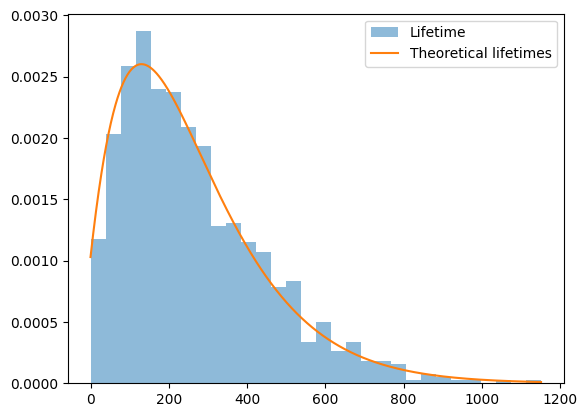

In [11]:
plt.hist(life_time, bins=30, alpha=0.5, label="Lifetime",density=True)
plt.plot(exp_pdf,label = "Theoretical lifetimes")

plt.legend()
plt.show()

## Task 4 

In [12]:
np.random.seed(42)
women_cancer_again = []
while len(women_cancer_again) != 1000: 
    X = sim_liftime_women(P)
    if (1 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

    elif (2 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

    elif (3 in X[:12]) and (len(X) > 12):
        women_cancer_again.append(X)

life_times_cancer_again = []
for elem in women_cancer_again:
    life_times_cancer_again.append(len(elem))


In [13]:
np.mean(life_times_cancer_again)

np.float64(179.99)

In [14]:
np.mean(life_time)

np.float64(266.035)

## Task 5 

In [ ]:
def crude_monte_carlo(n, n_womens):
    fractions = []
    for _ in range(n):
        dead_after_350 = 0
        for _ in range(n_womens):
            X = sim_liftime_women(P)
            if len(X) <350:
                dead_after_350 += 1
        fractions.append(dead_after_350/200)
    
    return np.mean(fractions), np.var(fractions)

In [ ]:
np.random.seed(42)
n_womens = 200
crude_monte_carlo(100)

np.float64(0.7348)

In [ ]:
def control_variate(n,n_womens): 
        X = np.zeros(len(n_womens))
        Z = []
        for i in range(n_womens):
            women = sim_liftime_women(P)
            Z.append(len(women))
            if len(women) < 350:
                X[i] = 1
        
        Z_mu = np.mean(Z)
        
            
            
        





# Task 12

In [8]:

### Can maybe be deleted once other tasks are put in
def sim_lifetime_women_rate(Q):
   state = 0
   time = 0 
   history = [(time,state)]


   while state != 4:
      rate = -Q[state,state]

      wait = np.random.exponential(1/rate)
      time += wait 

      probs = Q[state].copy()
      probs[state] = 0 

      probs = probs/rate

      state = np.random.choice(np.arange(5), p = probs)
      history.append((time,state))
      

   return history

def diag_elements(Q):
    for i in range(np.shape(Q)[0]):
        Q[i,i] = -np.sum(Q[i])
    return Q 

In [9]:
Simulations = []
Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0.0000, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0.0000,  0.0000, -0.0080, 0.0030, 0.0050],
    [ 0.0000,  0.0000,  0.0000, -0.0090, 0.0090],
    [ 0.0000,  0.0000,  0.0000, 0.0000, 0.0000]
])
np.random.seed(42)
for _ in range(1000):

    X = sim_lifetime_women_rate(Q)

    Yi = []
    i = 0

    for t in np.arange(0, X[-1][0] + 48, 48):

        while i + 1 < len(X) and X[i + 1][0] <= t:
            i += 1

        Yi.append(X[i][1])

        if Yi[-1] == 4:
            break

    Simulations.append(Yi)

# Task 13

In [10]:
def simulate_markov(X0, X_end, Q, t):

    state = X0
    time = 48 * t
    end_time = 48 * (t + 1)

    history = [(time, state)]

    while True:

        rate = -Q[state, state]

        if state == 4:  # No going on after death
            break

        wait = np.random.exponential(1 / rate)

        if time + wait > end_time:
            break

        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs /= rate

        state = np.random.choice(len(Q), p=probs)

        history.append((time, state))

    # state at end_time
    if state == X_end:
        return history
    else:
        return False

In [11]:
def create_Q(maxiter, eps, Q0):
    Q = Q0
    k =0
    dif = np.inf

    while (k <= maxiter) and (dif >=eps):
        # create the full Markov chain for all women
        all_women = []
        for woman in Simulations: 
            history = [(0,0)]
            for t in range(len(woman[:-1])): 
                his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                while his_subset == False: 
                    his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                history.extend(his_subset[1:])
            all_women.append(history)

        N = np.zeros(np.shape(Q))
        S = np.zeros(np.shape(Q)[0])


        for path in all_women:
            for (t1, s1), (t2, s2) in zip(path[:-1], path[1:]):
                if s1 != s2:
                    N[s1, s2]+=1
                    duration = t2-t1
                    S[s1] +=duration
        
        for i in range(len(S)-1):
            N[i] = N[i]/S[i]

        diag_elements(N)

        dif = np.linalg.norm((Q-N),ord=np.inf)
        k+=1
        Q = N 

    return Q

In [12]:
Q0 = np.array([
    [-0.04, 0.01, 0.01, 0.01,   0.01],
    [0.0, -0.03,    0.01,     0.01, 0.01],
    [0.0, 0.0,    -0.02,     0.01, 0.01],
    [0.0, 0.0,    0.0,     -0.01,   0.01],
    [0.0, 0.0,    0.0,     0.0,   0.0]
])
np.random.seed(42)
create_Q(10000,10**(-3) , Q0)

array([[-0.00846679,  0.00489381,  0.0023453 ,  0.00028787,  0.00093981],
       [ 0.        , -0.01441026,  0.00565939,  0.00361503,  0.00513584],
       [ 0.        ,  0.        , -0.00823644,  0.00277816,  0.00545828],
       [ 0.        ,  0.        ,  0.        , -0.0093765 ,  0.0093765 ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.        ]])

In [13]:
Q

array([[-0.0085,  0.005 ,  0.0025,  0.    ,  0.001 ],
       [ 0.    , -0.014 ,  0.005 ,  0.004 ,  0.005 ],
       [ 0.    ,  0.    , -0.008 ,  0.003 ,  0.005 ],
       [ 0.    ,  0.    ,  0.    , -0.009 ,  0.009 ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])